In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']



df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/probability_of_contact.csv')
df1['condition'] = 'GH'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/probability_of_contact.csv')
df2['condition'] = 'SI'


df = pd.concat([df1, df2], ignore_index=True)


condition_order = ['GH', 'SI']

condition_colors = {
    "SI": 'salmon',     
    "GH": 'steelblue',}

# only complete encounters: the larva came within 10 mm and left again
complete = df[df['end_reason'] == 'exit']

print(complete.groupby('condition').size())


condition
GH    12630
SI    12600
dtype: int64


comparison    U        p significance
  GH vs SI 69.0 0.161972           ns

           p_contact  n_files
condition                    
GH             0.353       10
SI             0.301       10


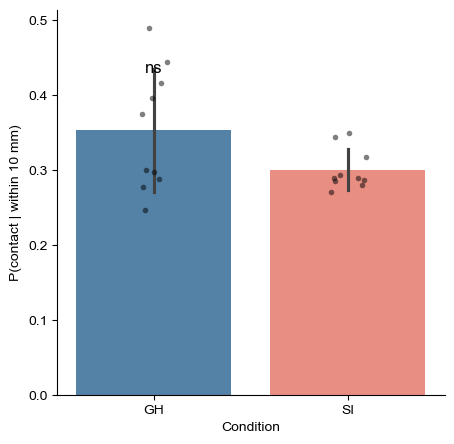

In [2]:
from scipy.stats import mannwhitneyu

# probability of contact per larva, then averaged per dish
per_larva = (
    complete.groupby(['condition', 'file', 'focal_id'], as_index=False)
            .agg(p_contact=('contacted', 'mean'), n_encounters=('contacted', 'size'))
)

per_file = (
    per_larva.groupby(['condition', 'file'], as_index=False)
             .agg(p_contact=('p_contact', 'mean'), n_encounters=('n_encounters', 'mean'))
)

MEASURE = 'p_contact'

comparisons = [
    ('GH', 'SI'),
]

stats_rows = []

for test, reference in comparisons:

    test_group = per_file.loc[per_file['condition'] == test, MEASURE]
    ref_group = per_file.loc[per_file['condition'] == reference, MEASURE]

    u_stat, p_value = mannwhitneyu(test_group, ref_group, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{test} vs {reference}',
        'test': test,
        'reference': reference,
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table[['comparison', 'U', 'p', 'significance']].to_string(index=False))

print()
print(per_file.groupby('condition').agg(p_contact=('p_contact', 'mean'), n_files=('file', 'size')).round(3))

plt.figure(figsize=(5,5))

ax = sns.barplot(
    data=per_file,
    x='condition',
    y=MEASURE,
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

sns.stripplot(
    data=per_file,
    x='condition',
    y=MEASURE,
    order=condition_order,
    color='black',
    size=4,
    alpha=0.5,
    ax=ax,
)

y_offset = per_file[MEASURE].max() * 0.15
for row in stats_rows:
    x = condition_order.index(row['test'])
    y = per_file.loc[per_file['condition'] == row['test'], MEASURE].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel('P(contact | within 10 mm)')
plt.xlabel('Condition')
sns.despine()
plt.show()


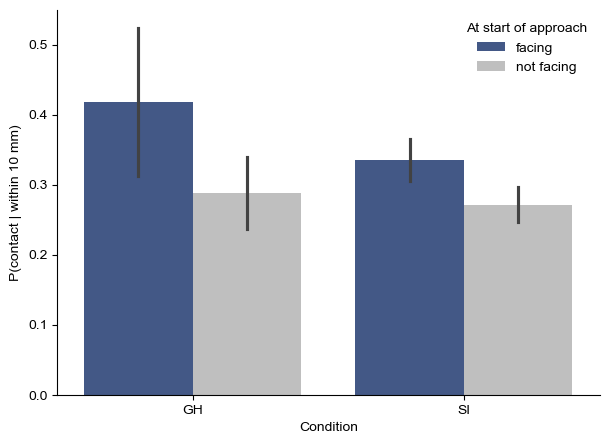

approach   facing  not facing
condition                    
GH          0.418       0.288
SI          0.335       0.271


In [3]:
# same thing, split by whether the larva was pointing at the other one at the start

per_larva_angle = (
    complete.groupby(['condition', 'file', 'focal_id', 'facing_at_start'], as_index=False)
            .agg(p_contact=('contacted', 'mean'), n_encounters=('contacted', 'size'))
)

per_file_angle = (
    per_larva_angle.groupby(['condition', 'file', 'facing_at_start'], as_index=False)
                   .agg(p_contact=('p_contact', 'mean'))
)

per_file_angle['approach'] = np.where(
    per_file_angle['facing_at_start'], 'facing', 'not facing'
)

plt.figure(figsize=(7,5))

sns.barplot(
    data=per_file_angle,
    x='condition',
    y='p_contact',
    order=condition_order,
    hue='approach',
    hue_order=['facing', 'not facing'],
    palette=['#385491', '#bfbfbf'],
    errorbar='sd',
)

plt.ylim(0, None)
plt.ylabel('P(contact | within 10 mm)')
plt.xlabel('Condition')
plt.legend(title='At start of approach', frameon=False)
sns.despine()
plt.show()

print(per_file_angle.groupby(['condition', 'approach'])['p_contact'].mean().unstack().round(3))


comparison    U        p significance
  GH vs SI 53.0 0.850107           ns


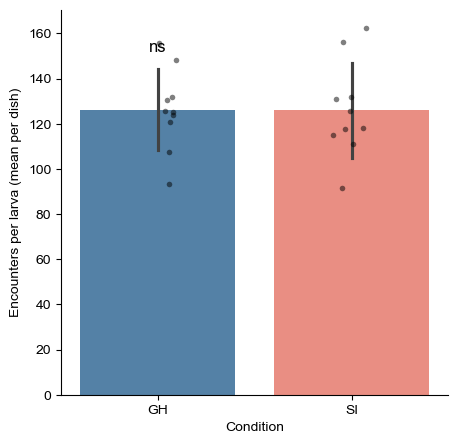

In [4]:
# how often they meet at all, so a difference in probability isn't confused with a difference in encounter rate

MEASURE = 'n_encounters'

comparisons = [
    ('GH', 'SI'),
]

stats_rows = []

for test, reference in comparisons:

    test_group = per_file.loc[per_file['condition'] == test, MEASURE]
    ref_group = per_file.loc[per_file['condition'] == reference, MEASURE]

    u_stat, p_value = mannwhitneyu(test_group, ref_group, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{test} vs {reference}',
        'test': test,
        'reference': reference,
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table[['comparison', 'U', 'p', 'significance']].to_string(index=False))

plt.figure(figsize=(5,5))

ax = sns.barplot(
    data=per_file,
    x='condition',
    y=MEASURE,
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

sns.stripplot(
    data=per_file,
    x='condition',
    y=MEASURE,
    order=condition_order,
    color='black',
    size=4,
    alpha=0.5,
    ax=ax,
)

y_offset = per_file[MEASURE].max() * 0.15
for row in stats_rows:
    x = condition_order.index(row['test'])
    y = per_file.loc[per_file['condition'] == row['test'], MEASURE].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel('Encounters per larva (mean per dish)')
plt.xlabel('Condition')
sns.despine()
plt.show()
